# Euclid Forward model

In [18]:
'''
github repo:
https://github.com/mgatti29/LSS_forward_model/tree/main

for nersc users:
source activate /global/cfs/cdirs/m5099/env/pyccl_env

this notebook:
/global/cfs/cdirs/m5099/GowerSt2/Tutorial/Examples/Tutorial.ipynb
'''

'\ngithub repo:\nhttps://github.com/mgatti29/LSS_forward_model/tree/main\n\nfor nersc users:\nsource activate /global/cfs/cdirs/m5099/env/pyccl_env\n\nthis notebook:\n/global/cfs/cdirs/m5099/GowerSt2/Tutorial/Examples/Tutorial.ipynb\n'

In [19]:
%matplotlib inline
import matplotlib.pyplot as plt
import LSS_forward_model
from LSS_forward_model.cosmology import *
from LSS_forward_model.lensing import *
from LSS_forward_model.maps import *
from LSS_forward_model.halos import *
from LSS_forward_model.tsz import *
from LSS_forward_model.theory import *
import os
import pandas as pd
import numpy as np
import healpy as hp
from cosmology import Cosmology
import astropy.io.fits as fits
import copy
import glass
import BaryonForge as bfn
import frogress

# Configurations

In [20]:
# Choose one dataset
data = 'LensMC_North'
# options: 'RR2', 'LensMC_North', 'LensMC_South', 'MetaCal_North', 'MetaCal_South'


# Path to the simulation products on NERSC.
path_simulation = '/global/cfs/cdirs/m5099/GowerSt2/Fiducial/1_big/'


# general settings ----------------------------------
nside_maps = 1024

# nuisance parameters ------------------------------
nuisance_parameters = dict()

# Photometric redshift shifts per tomographic bin
nuisance_parameters['dz'] = [0,0,0,0,0,0,0]

# Multiplicative shear calibration per bin
nuisance_parameters['dm'] = [1,1,1,1,1,1,1]

# Intrinsic alignment amplitude and redshift evolution
nuisance_parameters['A_IA'] = 0.
nuisance_parameters['A_IA2'] = 0.
nuisance_parameters['eta_IA'] = 0.
nuisance_parameters['bias_TA'] = [0.,0.,0.,0.,0.,0.,0.]
    

# Source clustering / source bias correction per bin
nuisance_parameters['bias_sc'] = [1,1,1,1,1,1,1]

# Global shear rotation angle
nuisance_parameters['rot'] = 0


# ------------------------------------------------------------
# Optional baryonification settings
# ------------------------------------------------------------

baryons = {
    "enabled": False,
    "max_z_halo_catalog": 1.5,
    "mass_cut": 13,
    "do_tSZ": False,
    "base_params_path": "../Data/Baryonification_default_parameters.npy",
    "filename_new_params": "sys_baryo_0.npy",
    "values_to_update": None,
}




# Read cosmology

In [21]:
# ============================================================
# Read simulation cosmology and auxiliary inputs
# ============================================================

# Read the simulation cosmology and build the corresponding cosmology bundle
sims_parameters, cosmo_bundle = read_sims_params(path_simulation)

# Add nuisance parameters to the simulation/cosmology dictionary
sims_parameters.update(nuisance_parameters)

# Load or create the baryonification parameter file.
# If baryons["enabled"] is False, these parameters are read but not applied later.
bpar, sys = load_or_save_updated_params(
    path_simulation,
    baryons["base_params_path"],
    baryons["filename_new_params"],
    baryons["values_to_update"],
    overwrite=False,
)

# Add baryonic-systematics parameters to the global parameter dictionary
sims_parameters.update(sys)

# Recover shell information: shell edges, redshifts, distances, etc.
shells_info = recover_shell_info(
    path_simulation + "/z_values.txt",
    max_z=49,
)

# Load source-clustering corrections for the selected data configuration
if data == "RR2":
    SC_corrections = np.load(
        "../Data/SC_RR2_fit_nov6.npy",
        allow_pickle=True,
    ).item()
else:
    SC_corrections = np.load(
        f"/global/homes/m/mgatti/LSS_forward_model/Data/SC_{data}.npy",
        allow_pickle=True,
    ).item()

In [4]:
print (shells_info.keys())

dict_keys(['Step', 'z_far', 'z_near', 'delta_z', 'cmd_far', 'cmd_near', 'delta_cmd', 'z_edges', 'mean_z'])


In [5]:
print (cosmo_bundle.keys())

dict_keys(['cosmo_pyccl', 'pars_camb', 'colossus_params', 'cosmo_astropy'])


# Setup n(z)

In [23]:
# ============================================================
# Load and prepare redshift distributions n(z)
# ============================================================

if data == "RR2":
    nz_data = np.load(
        "/global/cfs/cdirs/m5099/RR2/Reg2_SHE_tombins_unitweights_nz_SOMbin_C2020z_rebinned.npy",
        allow_pickle=True,
    ).item()

elif data in ["LensMC_North", "LensMC_South"]:
    nz_data = np.load(
        "/global/cfs/cdirs/m5099/TR1/WL/nz_TR1_LensMC.npy",
        allow_pickle=True,
    ).item()

elif data in ["MetaCal_North", "MetaCal_South"]:
    nz_data = np.load(
        "/global/cfs/cdirs/m5099/TR1/WL/nz_TR1_metacal.npy",
        allow_pickle=True,
    ).item()

else:
    raise ValueError(f"Unknown data configuration: {data}")


# Apply photo-z shifts and project n(z) onto the simulation shells
nz_shifted, shells, steps, zeff_glass, ngal_glass = apply_nz_shifts_and_build_shells(
    z_rebinned=nz_data["z_rebinned"],
    nz_all=nz_data["nz_rebinned"],
    dz_values=sims_parameters["dz"],
    shells_info=shells_info,
)

# Note: 
# -------------------------------------------------------
# nz_shifted and nz_data["z_rebinned"] describe the shifted n(z)
# on the original redshift grid. used for theory predictions

# -------------------------------------------------------
# ngal_glass and zeff_glass are the effective galaxy counts and
# effective redshifts after projecting the n(z) onto the simulation shells.
# This is the quantity actually used to generate the lensing maps, and it
# correctly accounts for the finite shell widths.


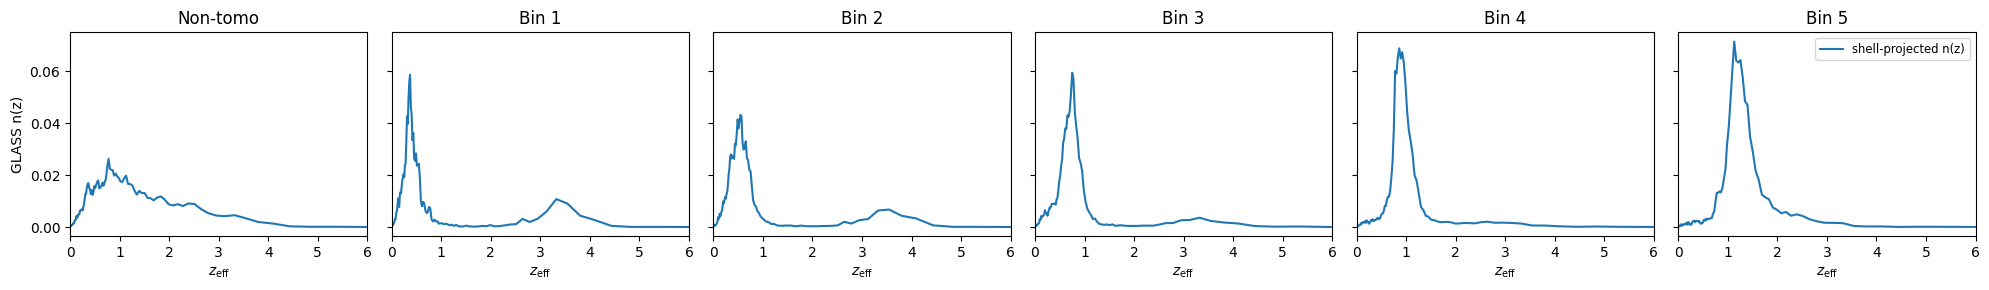

In [24]:
# ============================================================
# Plot shell-projected redshift distributions
# ============================================================

fig, axes = plt.subplots(1, 6, figsize=(20, 3), sharey=True)

titles = ["Non-tomo"] + [f"Bin {i}" for i in range(1, 6)]

for i, ax in enumerate(axes):
    ax.plot(zeff_glass, ngal_glass[i], label="shell-projected n(z)")
    ax.set_xlim(0, 6)
    ax.set_title(titles[i])
    ax.set_xlabel(r"$z_\mathrm{eff}$")

    if i == 0:
        ax.set_ylabel("GLASS n(z)")

axes[-1].legend(loc="upper right", fontsize="small")
plt.tight_layout()
plt.show()

# Compute density/kappa (with or without baryonification)

In [8]:
# ============================================================
# Generate lensing fields from simulation shells
# ============================================================

# Load matter-density shells and optionally apply baryonification.
# The output density field is the 3D lightcone/shell representation
# that will be projected into lensing observables.
density, label_baryonification = load_and_baryonify_gower_st_shells(
    path_simulation=path_simulation,
    sims_parameters=sims_parameters,
    cosmo_bundle=cosmo_bundle,
    baryons=baryons,
    nside_maps=nside_maps,
    shells_info=shells_info,
    shells=shells,
)

# Project density shells into weak-lensing fields:
# - kappa: convergence
# - shear: gamma1/gamma2
# - IA: intrinsic-alignment contribution, if enabled by A_IA / eta_IA
fields = compute_lensing_fields(density,shells,cosmo_bundle["pars_camb"],nside_maps,
    do_kappa=True,
    do_shear=True,
    do_IA=True,
)

# Keep the input density shells together with the projected fields
fields["density"] = density

# 2D TT [experimental] --------
fields['IA_shear_TT'] = make_TT_from_delta(fields['IA_shear'], fields['density'])

100.0% | [##########] | Progress: 100 / 100 | Time: 55.4s | ETA: --            

In [27]:
fields.keys()

dict_keys(['kappa', 'gamma', 'IA_shear', 'density', 'IA_shear_TT'])

Text(0.5, 1.0, 'mean z: 0.548616')

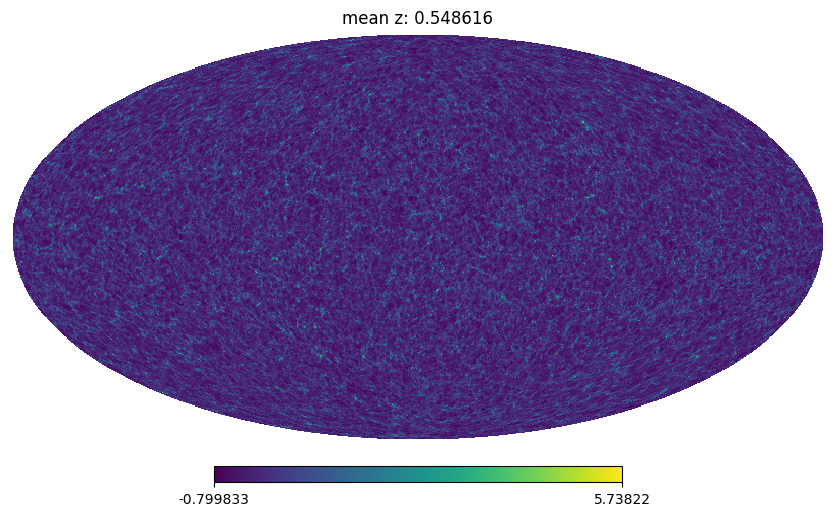

In [25]:
hp.mollview(hp.ud_grade(fields["density"][40],nside_out = 128))
plt.title('mean z: {0:2f}'.format(zeff_glass[40]))

# Theory checks

In [10]:
# Build Limber theory prediction for the same cosmology
theory = LimberTheory(
    cosmo_bundle["pars_camb"],
    lmax=4000,
    nonlinear="euclidemu",  # options: "euclidemu", "mead", "halofit"
)

# Set continuous shifted n(z), used for theory prediction
theory.set_Wshear(
    np.vstack([nz_data["z_rebinned"], nz_shifted]).T
)

# Theory convergence/shear C_ell between tomographic bins
Ckk_theory = theory.cl_gg(nonlinear=True)




# Integrate shell-level kappa maps using the shell-projected n(z)
kappa_tomo = integrate_field(
    ngal_glass,
    fields["kappa"],
)

# Measure auto-C_ell from the forward-model maps
Cls_maps = np.array([
    hp.anafast(kappa_tomo[tomo, :])
    for tomo in range(len(ngal_glass))
])


100.0% | [##########] | Progress: 4000 / 4000 | Time: 2.9s | ETA: --           

/tmp/ipykernel_1128441/2892868453.py:10: RuntimeWarning: divide by zero encountered in divide
  ratio = Cls_maps[tomo, :ell_max] / (


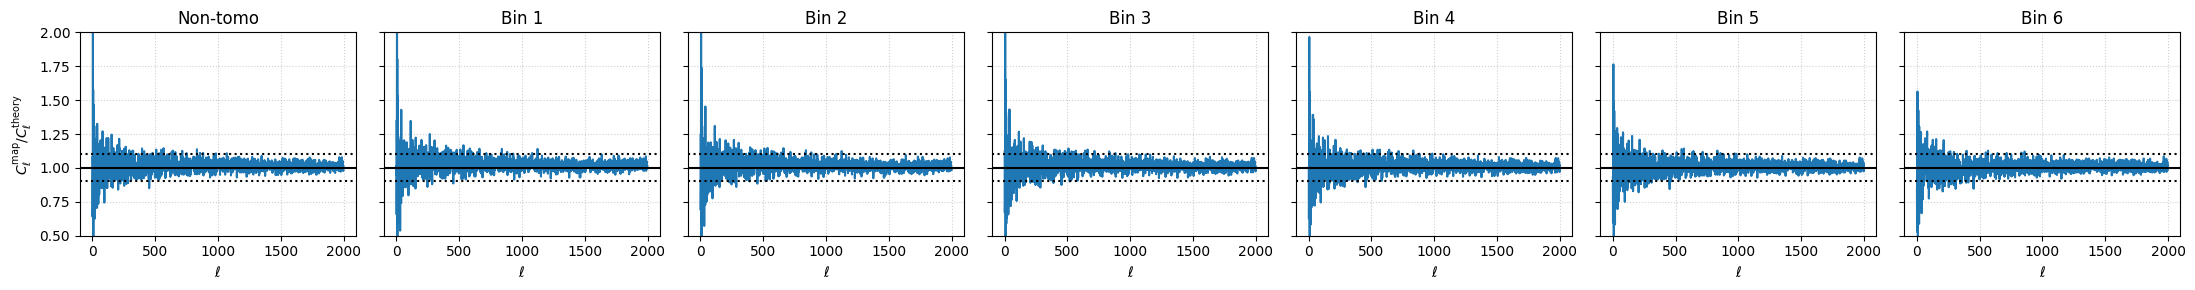

In [11]:
ell_max = 2000
ells = np.arange(ell_max)
pixwin = hp.pixwin(nside_maps)[:ell_max]

fig, axes = plt.subplots(1, 7, figsize=(22, 3), sharey=True)

titles = ["Non-tomo"] + [f"Bin {i}" for i in range(1, 7)]

for tomo, ax in enumerate(axes):
    ratio = Cls_maps[tomo, :ell_max] / (
        Ckk_theory[tomo, tomo, :ell_max] * pixwin**2
    )

    ax.plot(ells, ratio)
    ax.axhline(1.0, color="black")
    ax.axhline(0.9, color="black", ls=":")
    ax.axhline(1.1, color="black", ls=":")

    ax.set_ylim(0.5, 2.0)
    ax.set_title(titles[tomo])
    ax.set_xlabel(r"$\ell$")
    ax.grid(True, which="both", ls=":", alpha=0.6)

axes[0].set_ylabel(r"$C_\ell^\mathrm{map} / C_\ell^\mathrm{theory}$")

plt.tight_layout()
plt.show()

# make simulated maps with source clustering

In [12]:
# ============================================================
# Build Euclid-like weak-lensing maps
# ============================================================

# Load the Euclid/RR2 or TR1 catalog information used to define
# the footprint, number density, masks, and survey realism.
if data == "RR2":
    path_data_cats = "/global/cfs/cdirs/m5099/RR2/Euclid_cats.npy"
else:
    path_data_cats = f"/global/cfs/cdirs/m5099/TR1/{data}.npy"

cats_Euclid = np.load(path_data_cats, allow_pickle=True).item()


# Convert ideal simulated lensing fields into Euclid-like WL maps.
# This step can include:
# - survey footprint / mask
# - source number density
# - shape noise
# - multiplicative shear calibration
# - source-clustering corrections
# - optional catalog-level outputs
maps_Gower_WL, cat_Gower_WL = make_WL_sample(
    ngal_glass=ngal_glass,
    zeff_glass=zeff_glass,
    cosmo_bundle=cosmo_bundle,
    sims_parameters=sims_parameters,
    nside_maps=nside_maps,
    fields=fields,
    cats_Euclid=cats_Euclid,
    SC_corrections=SC_corrections,
    do_catalog=False,
    include_SC=True,
)

# save them ----
print ('done')

# Make data maps &  Kaiser-Squires

In [13]:
# load some maps I already made ----
path_simulation = "/global/cfs/cdirs/m5099/GowerSt2/Fiducial/11_big/"
maps_Gower_WL = np.load(f"{path_simulation}/test_{data}.npy",allow_pickle=True,).item()["maps"]




# ============================================================
# Make data shear maps
# ============================================================
tomo = 0
cat = cats_Euclid[tomo]

pix = convert_to_pix_coord(cat["ra"], cat["dec"], nside=nside_maps)
unique_pix, _, idx_rep = np.unique(pix, return_index=True, return_inverse=True)

npix = hp.nside2npix(nside_maps)

n_map = np.zeros(npix)
e1_map = np.zeros(npix)
e2_map = np.zeros(npix)

n_map[unique_pix] = np.bincount(idx_rep, weights=cat["w"], minlength=len(unique_pix))
e1_map[unique_pix] = np.bincount(idx_rep, weights=cat["e1"] * cat["w"], minlength=len(unique_pix))
e2_map[unique_pix] = np.bincount(idx_rep, weights=cat["e2"] * cat["w"], minlength=len(unique_pix))

mask = n_map > 0
e1_map[mask] /= n_map[mask]
e2_map[mask] /= n_map[mask]

In [14]:
# ============================================================
# Kaiser-Squires maps: data and simulations
# ============================================================

E_data, B_data, _, _ = g2k_sphere(
    e1_map,
    -e2_map,   # sign convention for data catalog
    mask=mask,
    nside=nside_maps,
    lmax=2*nside_maps,
)

sim = maps_Gower_WL[tomo]


E_sim, B_sim, _, _ = g2k_sphere(
    sim["e1"],
    sim["e2"],
    mask=mask,
    nside=nside_maps,
    lmax=2*nside_maps,
)

E_data[~mask] = 0
E_sim[~mask] = 0

/global/u2/m/mgatti/LSS_forward_model/LSS_forward_model/maps.py:336: RuntimeWarning: divide by zero encountered in divide
  almsE = alms[1] * 1. * ((ell * (ell + 1.)) / ((ell + 2.) * (ell - 1))) ** 0.5
/global/u2/m/mgatti/LSS_forward_model/LSS_forward_model/maps.py:336: RuntimeWarning: invalid value encountered in multiply
  almsE = alms[1] * 1. * ((ell * (ell + 1.)) / ((ell + 2.) * (ell - 1))) ** 0.5
/global/u2/m/mgatti/LSS_forward_model/LSS_forward_model/maps.py:337: RuntimeWarning: divide by zero encountered in divide
  almsB = alms[2] * 1. * ((ell * (ell + 1.)) / ((ell + 2.) * (ell - 1))) ** 0.5
/global/u2/m/mgatti/LSS_forward_model/LSS_forward_model/maps.py:337: RuntimeWarning: invalid value encountered in multiply
  almsB = alms[2] * 1. * ((ell * (ell + 1.)) / ((ell + 2.) * (ell - 1))) ** 0.5


In [15]:
# ============================================================
# Smooth at 100 arcmin
# ============================================================
smooth_arcmin = 100.
fwhm = np.radians(smooth_arcmin / 60)

E_data_sm = hp.smoothing(E_data, fwhm=fwhm)
E_sim_sm = hp.smoothing(E_sim, fwhm=fwhm)

E_data_sm[~mask] = 0
E_sim_sm[~mask] = 0

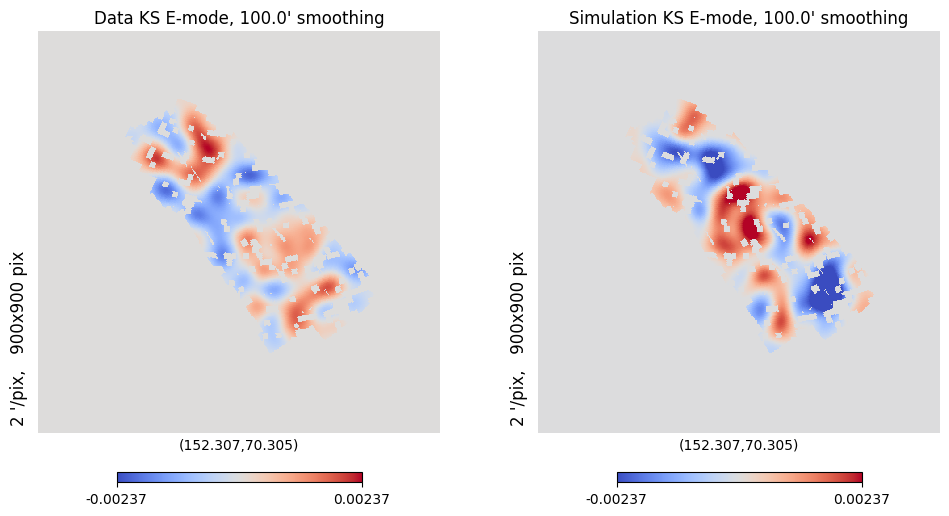

In [16]:
# ============================================================
# Plot
# ============================================================

def get_patch_center(m, threshold=0):
    nside = hp.get_nside(m)
    pix = np.where(np.abs(m) > threshold)[0]
    theta, phi = hp.pix2ang(nside, pix)

    lon = np.degrees(phi)
    lat = 90 - np.degrees(theta)

    lon_rad = np.radians(lon)
    lon0 = np.degrees(
        np.arctan2(np.mean(np.sin(lon_rad)), np.mean(np.cos(lon_rad)))
    ) % 360
    lat0 = np.mean(lat)

    return lon0, lat0


lon0, lat0 = get_patch_center(E_data_sm)

vmax = np.nanmax(np.abs(E_data_sm))
vmin = -vmax

plt.figure(figsize=(10, 5))

hp.gnomview(
    E_data_sm,
    rot=(lon0, lat0, 0),
    xsize=900,
    ysize=900,
    reso=2.0,
    sub=(1, 2, 1),
    title=f"Data KS E-mode, {smooth_arcmin}' smoothing",
    min=vmin,
    max=vmax,
    cmap="coolwarm",
)

hp.gnomview(
    E_sim_sm,
    rot=(lon0, lat0, 0),
    xsize=900,
    ysize=900,
    reso=2.0,
    sub=(1, 2, 2),
    title=f"Simulation KS E-mode, {smooth_arcmin}' smoothing",
    min=vmin,
    max=vmax,
    cmap="coolwarm",
)

plt.show()